## Libraries and Packages

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

**Optical flow**

Optical flow is a computer vision technique that analyzes the apparent motion of objects, surfaces, and edges in a visual scene between consecutive frames of a video. It essentially calculates the displacement of pixels or features, creating a vector field that represents the direction and magnitude of movement. This information is crucial for understanding scene dynamics and enabling various AI and machine learning applications.

**Lucas-Kanade**

The Lucas-Kanade method is a widely used technique in computer vision for estimating optical flow, which is the pattern of apparent motion of objects in a visual scene between consecutive frames. It works by assuming that the motion of pixels within a small neighborhood is relatively constant and using this assumption to solve for the motion vectors (optical flow) for those pixels. This method is particularly useful for tracking features and detecting motion in video sequences

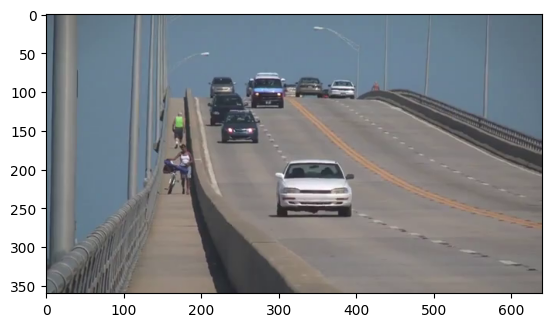

In [5]:
cap = cv2.VideoCapture('videos/slow_traffic_small.mp4')

while True:
    ret, frame = cap.read()
    
    if not ret:
        print("Exiting ...")
        break
    cv2.imshow('video', frame)
    if cv2.waitKey(1) & 0xFF == 27:
        plt.imshow(frame[...,::-1]);
        break

cap.release()
cv2.destroyAllWindows()

In [7]:
#Define params for ShiTomasi corner detection
feature_params = dict( maxCorners = 100,
                       qualityLevel = 0.3,
                       minDistance = 7,
                       blockSize = 7 )

# Parameters for lucas kanade optical flow
lk_params = dict( winSize  = (15, 15),
                  maxLevel = 2,
                  criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

# Create some random colors, in this case we have a lots of cars in our scenes, we wanna show their motions and optical flows with different colors
color = np.random.randint(0, 255, (100, 3))

**Shitomasi corner detection**

cv.goodFeaturesToTrack() -> R = min(landa1 and landa2)

In [9]:
cap = cv2.VideoCapture('videos/slow_traffic_small.mp4')

# Take first frame and find corners in it with Shitomasi corner detection
old_ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
interest_points = cv2.goodFeaturesToTrack(old_gray, mask = None, **feature_params)

# Create a mask image for drawing purposes
mask = np.zeros_like(old_frame)

In [11]:
while True:
    ret, frame = cap.read()
    if not ret:
        print('Exiting ...')
        break
    #Convert frame's RGB channel to grayscale, aim to pass this frame to LK algorithm
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # Calculate optical flow with Lucas-Kanade
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, interest_points, None, **lk_params)
    # Select good points
    if p1 is not None:
        #why we check st == 1? because for each points in new interest points, we have may lost the point!
        good_new = p1[st==1]
        good_old = interest_points[st==1]
    # Draw the tracks
    for i, (new, old) in enumerate(zip(good_new, good_old)):
        x1, y1 = new.ravel()
        x2, y2 = old.ravel()
        mask = cv2.line(mask, (int(x1), int(y1)), (int(x2), int(y2)), color[i].tolist(), 2)
        frame = cv2.circle(frame, (int(x1), int(y1)), 5, color[i].tolist(), -1)
    img = cv2.add(frame, mask)
    cv2.imshow('frame', img)
    k = cv2.waitKey(30) & 0xff
    if k == 27:
        break
    #Update the previous frame and previous points
    old_gray = frame_gray.copy()
    interest_points = good_new.reshape(-1, 1, 2)
cv2.destroyAllWindows()